### Imports

In [1]:
import math
import torch
import random
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib import colormaps

import gymnasium as gym
from MyoElbowPose2D6M import MyoElbowPose2D6MFixed

### Constants

In [2]:
# --- Simulation parameters ---
dt, tau_n, tau_m = 0.01, 0.02, 0.05

# --- Neural network parameters ---
n_s, n_m1, n_muscles, n_inputs = 200, 200, 6, 10

# --- Feedback gains ---
G_p, G_d, G_f = 1.0, 1.0, 1.0

# --- Reflex parameters ---
G_aff = torch.tensor([1.0, 0.1, 0.01, 0.0001])
G_s_low, G_s_high = 0.8, 1.9
reflex_delay = int(0.02 / dt)

# --- Activation and feedback delay ---
activation_delay_steps = int(0.03 / dt)
feedback_delay_steps = int(0.04 / dt) 

# --- Moment arm matrix ---
M_m = torch.tensor([[0.1, 0.02], [0.08, 0.01], [0.06, 0.01], [-0.06, -0.02], [-0.08, -0.01], [-0.1, -0.02]])

# --- Penalty coefficients ---
alpha, beta, gamma = 0.0001, 0.01, 0.5

# --- External loads ---
background_load_low, background_load_high, perturbation_load = 0.1, 0.55, 0.25

# --- Time parameters and steps ---
Tb, Tsb, Tp, Tsp, T = 0.20, 1.00, 1.50, 2.50, 3.00
Tb_step, Tsb_step, Tp_step, Tsp_step, T_step = int(Tb / dt), int(Tsb / dt), int(Tp / dt), int(Tsp / dt), int(T / dt)

# --- Perturbation directions ---
perturbation_directions = {
    "Right": np.array([1.0, 0.0]), "Left": np.array([-1.0, 0.0]), "Up": np.array([0.0, 1.0]), "Down": np.array([0.0, -1.0]),
    "Up-Right": np.array([0.707, 0.707]), "Up-Left": np.array([-0.707, 0.707]), "Down-Left": np.array([-0.707, -0.707]), "Down-Right": np.array([0.707, -0.707])}

# --- Arm segment lengths ---
l1, l2 = 0.3, 0.25

### Neural Limb Controller

In [3]:
class NeuralLimbController(nn.Module):
    """Neural controller for a two-segment limb model."""

    def __init__(self, n_inputs, n_outputs=n_muscles):
        super().__init__()
        
        # Sensory layer
        self.w_sr = self._init_weights(n_s, n_s, n_inputs)
        self.w_si = self._init_weights(n_s, n_inputs, n_inputs)
        self.b_s = nn.Parameter(torch.full((n_s,), 0.1))

        # M1 layer
        self.w_mr = self._init_weights(n_m1, n_m1, n_s)
        self.w_mi = self._init_weights(n_m1, n_s, n_s)
        self.b_m = nn.Parameter(torch.full((n_m1,), 0.1))

        # Muscle activation layer
        self.w_act = self._init_weights(n_muscles, n_m1, n_m1)

        # Internal state variables
        self.y_s = torch.zeros(n_s)
        self.y_m = torch.zeros(n_m1)
        self.y_act = torch.zeros(n_muscles)

    @staticmethod
    def _init_weights(out_dim, in_dim, scale_dim):
        """Helper function to initialize weights."""
        return nn.Parameter(torch.empty(out_dim, in_dim).uniform_(-1 / np.sqrt(scale_dim), 1 / np.sqrt(scale_dim)))
    
    def reset_states(self):
        """Reset the internal states of the controller."""
        self.y_s.zero_()
        self.y_m.zero_()
        self.y_act.zero_()

    def reset_weights(self):
        """Reinitialize the weights of the controller."""
        for param in [self.w_sr, self.w_si, self.w_mr, self.w_mi, self.w_act]:
            param.data.uniform_(-1 / np.sqrt(param.size(1)), 1 / np.sqrt(param.size(1)))

    def neural_activation_step(self, y_t, u_t):
        """Discretized neural activation dynamics."""
        return (1 - (dt / tau_n)) * y_t + (dt / tau_n) * torch.tanh(u_t)
    
    def muscle_activation_step(self, y_act_t, u_act_t):
        """Discretized muscle activation dynamics."""
        return (1 - (dt / tau_m)) * y_act_t + (dt / tau_m) * torch.relu(u_act_t)

    def forward_step(self, u_fb_t, x_aff_t, y_s_delayed_t, G_s):
        """Perform a single forward step of the neural controller."""
        self.y_s = self.neural_activation_step(self.y_s, self.w_sr @ y_s_delayed_t + self.w_si @ u_fb_t + self.b_s)
        self.y_m = self.neural_activation_step(self.y_m, self.w_mr @ self.y_m + self.w_mi @ self.y_s + self.b_m)
        self.y_act = self.muscle_activation_step(self.y_act, self.w_act @ self.y_m + G_s * x_aff_t)
        return self.y_act

### Hill-type muscle model equations

In [4]:
class MuscleConstants:
    """Class to store physiologically based constants for muscle dynamics."""
    F_MAX = 1.0               # Maximum isometric force (used for normalization)
    L_OPT = 1.0               # Optimal fiber length (used for normalization)
    V_MAX = 10.0              # Maximum shortening velocity (V_max / L_opt)

    # Coefficients for Shortening
    A_HILL = 0.25             # Normalized coefficient 'a/F_max'
    B_HILL = A_HILL * V_MAX   # Normalized coefficient 'b/L_opt'

    # Coefficients for Lengthening
    K_ECC = 0.15              # Shape factor for the eccentric regime
    F_MAX_ECC = 1.4           # Max force during lengthening (1.4 * F_max)


class ForceLength:
    """Class to compute the force-length relationship for muscles."""
    @staticmethod
    def compute(L_m, L_opt=MuscleConstants.L_OPT, width_factor=0.4):
        """
        Args:
            L_m (torch.Tensor): Normalized muscle length.
            L_opt (float): Optimal fiber length (default: 1.0).
            width_factor (float): Controls the width of the bell curve (default: 0.4).

        Returns:
            torch.Tensor: Force-Length scaling factor (FL).
        """
        exp = -((L_m - L_opt) / width_factor).pow(2)
        return torch.exp(exp)


class ForceVelocity:
    """Class to compute the force-velocity relationship for muscles."""
    @staticmethod
    def compute(dLm_dt, V_max=MuscleConstants.V_MAX, A_hill=MuscleConstants.A_HILL, 
                B_hill=MuscleConstants.B_HILL, F_max_ecc=MuscleConstants.F_MAX_ECC, 
                K_ecc=MuscleConstants.K_ECC):
        """
        Args:
            dLm_dt (torch.Tensor): Normalized muscle velocity (positive for lengthening, negative for shortening).
            V_max (float): Maximum shortening velocity.
            A_hill (float): Hill's coefficient 'a/F_max'.
            B_hill (float): Hill's coefficient 'b/L_opt'.
            F_max_ecc (float): Max force during lengthening.
            K_ecc (float): Shape factor for the eccentric regime.

        Returns:
            torch.Tensor: Force-Velocity scaling factor (FV).
        """
        # Shortening (dLm_dt <= 0): Hill's hyperbolic equation
        FV_shortening = (B_hill - dLm_dt) / (B_hill + A_hill * dLm_dt)
        # Lengthening (dLm_dt > 0): Exponential plateau
        FV_lengthening = (F_max_ecc - 1.0) * (1.0 - torch.exp(-K_ecc * dLm_dt)) + 1.0
        # Combine shortening and lengthening regimes
        return torch.where(dLm_dt <= 0.0, FV_shortening, FV_lengthening)

### Cost functions

In [5]:
def compute_costs(controller, qpos, qvel, F_m, J_b_1_accumulated, J_b_2_accumulated, J_p_accumulated):
    """Compute the neural, force, and kinematic costs."""
    # Neural cost (Instantaneous mean of squared activity)
    neural_cost = controller.y_s.pow(2).mean() + controller.y_m.pow(2).mean()

    # Force output cost (Instantaneous mean of squared force)
    force_cost = F_m.pow(2).mean()

    # Kinematic cost (Final Time-Averaged Costs)
    J_b_1_duration = Tb
    J_b_2_duration = Tp - Tsb
    J_p_duration = T - Tsp

    # Time-Averaged Cost = Integral / Duration
    J_b_1_final = J_b_1_accumulated / J_b_1_duration
    J_b_2_final = J_b_2_accumulated / J_b_2_duration
    J_p_final = J_p_accumulated / J_p_duration
    
    # J_b is the sum of its two components
    J_b_final = J_b_1_final + J_b_2_final
    
    # Total Kinematic Cost
    kinematic_cost = J_b_final + J_p_final

    return neural_cost, force_cost, kinematic_cost, J_b_final, J_p_final

def compute_weighted_costs(neural_cost, force_cost, kinematic_cost, J_b_final, J_p_final, alpha, beta, gamma):
    """Compute weighted components of the cost."""
    return {
        "neural": alpha * neural_cost,
        "force": beta * force_cost,
        "J_b": gamma * J_b_final,
        "J_p": gamma * J_p_final,
        "kinematic": gamma * kinematic_cost,
        "total": alpha * neural_cost + beta * force_cost + gamma * kinematic_cost,
    }

def compute_and_accumulate_costs(controller, qpos, qvel, F_m, J_b_1_accumulated, J_b_2_accumulated, J_p_accumulated, total_costs):
    """Compute costs, apply weights, and accumulate them into total_costs."""
    # Compute costs
    neural_cost, force_cost, kinematic_cost, J_b_final, J_p_final = compute_costs(controller, qpos, qvel, F_m, J_b_1_accumulated, J_b_2_accumulated, J_p_accumulated)
    weighted_costs = compute_weighted_costs(neural_cost, force_cost, kinematic_cost, J_b_final, J_p_final, alpha, beta, gamma)

    # Add L2 regularization to the total cost
    total_cost = weighted_costs["total"]
    l2_reg = 0.01 * sum(p.pow(2).sum() for p in controller.parameters())
    total_cost += l2_reg

    # Accumulate costs
    for key in total_costs:
            if key == "J_b":
                total_costs[key] += weighted_costs[key].item() 
            elif key == "J_p":
                total_costs[key] += weighted_costs[key].item()
            elif key == "neural" or key == "force":
                total_costs[key] += weighted_costs[key].item()
            elif key == "kinematic":
                total_costs[key] += weighted_costs[key].item()
            elif key == "total":
                total_costs[key] += weighted_costs[key].item()

    return total_cost

### Helper functions

In [6]:
def compute_jacobian(theta_s, theta_e, l1, l2):
    """Compute the Jacobian matrix for a 2D planar arm."""
    J = np.array([
        [-l1 * np.sin(theta_s) - l2 * np.sin(theta_s + theta_e), -l2 * np.sin(theta_s + theta_e)],
        [l1 * np.cos(theta_s) + l2 * np.cos(theta_s + theta_e),  l2 * np.cos(theta_s + theta_e)]
    ])
    return J

def apply_external_torque(step, Tb_step, Tp_step, Tsp_step, background_load, perturbation_load, direction_name, J):
    if step < Tb_step:
        return np.array([0.0, 0.0])
    elif Tb_step <= step < Tp_step:
        desired_force = background_load * perturbation_directions[direction_name]
    elif Tp_step <= step < Tsp_step:
        desired_force = (background_load + perturbation_load) * perturbation_directions[direction_name]
    else:
        desired_force = background_load * perturbation_directions[direction_name]
    return J.T @ desired_force

### Training Loop

In [7]:
# Initialize environment and controller
env = MyoElbowPose2D6MFixed()
controller = NeuralLimbController(n_inputs=n_inputs, n_outputs=n_muscles)

# Set up optimizer and scheduler
optimizer = torch.optim.Adam(controller.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

# Initialize results storage
target_results = {
    i: {
        "pose_errors": [],
        "rewards": [],
        "costs": {"neural": [], "force": [], "kinematic": [], "J_b": [], "J_p": [], "total": []},
        "spinal_contrib": [], "cortical_contrib": [], "muscle_activations": [],
        "reflex_gain": [], "cortical_activity": [], "sensory_activity": [], "motor_activity": []
    }
    for i in range(len(perturbation_directions))
}

In [8]:
# Training loop
num_epochs = 1000
epoch_metadata = []
epoch_qpos_over_time = []
epoch_external_loads = []
epoch_costs_over_time = []

for epoch in range(num_epochs):
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}")

    # Reset controller and environment
    controller.reset_weights()
    controller.reset_states()
    obs, _ = env.reset(target_qpos=(0.0, 0.0))

    # Randomly select load condition and perturbation direction
    background_load = random.choice([background_load_low, background_load_high])
    load_condition = "High" if background_load == background_load_high else "Low"
    G_s = G_s_high if background_load == background_load_high else G_s_low
    perturbation_idx = random.randint(0, len(perturbation_directions) - 1)
    direction_name = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"][perturbation_idx]
    epoch_metadata.append({"load": load_condition, "direction": direction_name})

    # Select a random perturbation direction
    desired_force = perturbation_directions[direction_name]

    # Initialize accumulators and buffers
    J_b_1_accumulated = torch.tensor(0.0, requires_grad=True)
    J_b_2_accumulated = torch.tensor(0.0, requires_grad=True)
    J_p_accumulated = torch.tensor(0.0, requires_grad=True)
    total_costs = {"neural": 0.0, "force": 0.0, "J_b": 0.0, "J_p": 0.0, "kinematic": 0.0, "total": 0.0}
    activation_buffer = [torch.zeros(n_muscles) for _ in range(activation_delay_steps)]
    delayed_activations = activation_buffer[0]

    # Storage for this epoch
    pose_errors, rewards, qpos_over_time, external_load_over_time = [], [], [], []
    epoch_costs = {key: [] for key in total_costs.keys()}

    # Initialize muscle kinematics
    L_m = torch.tensor([1.05, 1.02, 1.00, 0.98, 0.97, 0.99], requires_grad=True)
    L_m_initial = L_m.clone().detach()
    delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m = [torch.zeros(n_muscles) for _ in range(4)]

    for step in range(T_step):
        # Detach internal states
        for state in [controller.y_s, controller.y_m, controller.y_act]:
            state.detach_()

        # Get current observation
        theta_s, theta_e = obs[0], obs[2]

        # Compute Jacobian and apply external torque
        theta_s, theta_e = obs[0], obs[2]
        J = compute_jacobian(theta_s, theta_e, l1, l2)
        tau = apply_external_torque(step, Tb_step, Tp_step, Tsp_step, background_load, perturbation_load, direction_name, J)
        env.set_external_torque(tau)
        external_load_over_time.append(tau.copy())

        # Compute pose error
        target_qpos = (0.0, 0.0)
        pose_error = np.sqrt((target_qpos[0] - obs[0])**2 + (target_qpos[1] - obs[2])**2)

        # Compute kinematic loss term
        kinematic_loss_term = (torch.tensor(obs[:2]) - torch.tensor(target_qpos)).pow(2).mean() + 0.5 * torch.tensor(obs[1:3]).pow(2).mean()
        kinematic_loss_integral = kinematic_loss_term * dt

        # Accumulate kinematic costs
        if step < Tb_step:
            with torch.no_grad():
                J_b_1_accumulated += kinematic_loss_integral.detach()
            # Reset other costs to ensure they don't accumulate outside their phase
            J_b_2_accumulated = torch.tensor(0.0, requires_grad=True)
            J_p_accumulated = torch.tensor(0.0, requires_grad=True)

        elif Tsb_step <= step < Tp_step:
            with torch.no_grad():
                J_b_2_accumulated += kinematic_loss_integral.detach()
            # Reset other costs
            J_b_1_accumulated = torch.tensor(0.0, requires_grad=True)
            J_p_accumulated = torch.tensor(0.0, requires_grad=True)

        elif Tp_step <= step < Tsp_step:
            with torch.no_grad():
                J_p_accumulated += kinematic_loss_integral.detach()
            # Reset other costs
            J_b_1_accumulated = torch.tensor(0.0, requires_grad=True)
            J_b_2_accumulated = torch.tensor(0.0, requires_grad=True)

        # Compute muscle length changes
        dLm_dt = (-M_m @ torch.tensor(obs[1:3], dtype=torch.float32).unsqueeze(1)).squeeze()
        new_L_m = L_m + dLm_dt * dt
        new_L_m, dLm_dt = new_L_m.detach(), dLm_dt.detach()

        # Update muscle kinematics
        new_delta_L_m = new_L_m - L_m_initial
        new_velocity_L_m = dLm_dt
        new_acceleration_L_m = (new_velocity_L_m - velocity_L_m) / dt
        new_jerk_L_m = (new_acceleration_L_m - acceleration_L_m) / dt

        L_m, delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m = new_L_m, new_delta_L_m, new_velocity_L_m, new_acceleration_L_m, new_jerk_L_m
        x_m = torch.stack([delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m], dim=1)
        x_aff_t = G_aff @ x_m.T

        # Compute muscle forces and feedback
        FL = ForceLength.compute(L_m)
        FV = ForceVelocity.compute(dLm_dt.squeeze())
        F_m = delayed_activations * FL * FV

        qpos = torch.tensor([obs[0], obs[2]], dtype=torch.float32)  # Joint positions
        qvel = torch.tensor([obs[1], obs[3]], dtype=torch.float32)  # Joint velocities
        position_error = G_p * (qpos - torch.tensor(target_qpos, dtype=torch.float32))
        velocity_feedback = G_d * qvel
        force_feedback = G_f * F_m
        u_fb = torch.cat([position_error, velocity_feedback, force_feedback], dim=0)

        # Generate muscle activations
        u_fb_t = u_fb
        muscle_activations = controller.forward_step(u_fb_t=u_fb_t, x_aff_t=x_aff_t, y_s_delayed_t=controller.y_s, G_s=G_s)

        # Apply activation delay
        delayed_activations = activation_buffer.pop(0)
        activation_buffer.append(muscle_activations)

        # Compute and accumulate costs
        total_cost = compute_and_accumulate_costs(controller, qpos, qvel, F_m, J_b_1_accumulated, J_b_2_accumulated, J_p_accumulated, total_costs)
        total_cost *= 1000

        # Debugging: Compute individual costs and print them
        neural_cost, force_cost, kinematic_cost, J_b, J_p = compute_costs(controller, qpos, qvel, F_m, J_b_1_accumulated, J_b_2_accumulated, J_p_accumulated)
        weighted_costs = compute_weighted_costs(neural_cost, force_cost, kinematic_cost, J_b, J_p, alpha, beta, gamma)

        # Scale the costs for debugging
        scaled_weighted_costs = {key: value * 1000 for key, value in weighted_costs.items()}

        # Store step-by-step costs
        for key in epoch_costs.keys():
            epoch_costs[key].append(scaled_weighted_costs[key])

        # if step % 50 == 0:  # Print every 50 steps
        #     print(f"Epoch {epoch + 1}, Step {step} | Neural Cost: {scaled_weighted_costs['neural']:.4f} | "
        #         f"Force Cost: {scaled_weighted_costs['force']:.4f} | Kinematic Cost: {scaled_weighted_costs['kinematic']:.4f} | "
        #         f"J_b: {scaled_weighted_costs['J_b']:.4f} | J_p: {scaled_weighted_costs['J_p']:.4f} | "
        #         f"Total Cost: {scaled_weighted_costs['total']:.4f}")

        # Backpropagation
        optimizer.zero_grad()
        total_cost.backward()
        torch.nn.utils.clip_grad_norm_(controller.parameters(), max_norm=1.0)
        optimizer.step()

        # Step the environment
        obs, reward, terminated, truncated, info = env.step(muscle_activations.detach().numpy())
        pose_errors.append(pose_error)
        rewards.append(reward)
        x = l1 * np.cos(obs[0]) + l2 * np.cos(obs[0] + obs[2])
        y = l1 * np.sin(obs[0]) + l2 * np.sin(obs[0] + obs[2])
        qpos_over_time.append((x, y))

    # Store epoch results
    epoch_qpos_over_time.append(qpos_over_time) 
    epoch_external_loads.append(external_load_over_time)
    epoch_costs_over_time.append(epoch_costs) 

    target_results[perturbation_idx]["pose_errors"].append(pose_errors)
    target_results[perturbation_idx]["rewards"].append(rewards)
    for key in epoch_costs.keys():
        target_results[perturbation_idx]["costs"][key].append(total_costs[key])

    # Post-epoch processing
    scheduler.step()

Epoch 100/1000
Epoch 200/1000
Epoch 300/1000
Epoch 400/1000
Epoch 500/1000
Epoch 600/1000
Epoch 700/1000
Epoch 800/1000
Epoch 900/1000
Epoch 1000/1000


### Plots

In [9]:
def pad_and_compute_mean_std(data, max_length):
    """Pad data with NaN to the maximum length and compute mean and standard deviation."""
    padded_data = np.array([np.pad(epoch, (0, max_length - len(epoch)), constant_values=np.nan) for epoch in data])
    mean = np.nanmean(padded_data, axis=0)
    std = np.nanstd(padded_data, axis=0)
    return mean, std

def plot_mean_and_std(ax, x, mean, std, label, color, line_style="solid", alpha=0.1):
    """Plot mean and standard deviation as a shaded region."""
    ax.plot(x, mean, label=label, color=color, linestyle=line_style)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=alpha)

def plot_pose_error(ax, perturbation_results):
    """Plot pose error over time for all perturbations."""
    # Define perturbation direction names
    perturbation_names = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]
    num_perturbations = len(perturbation_results)
    colormap = colormaps["tab10"].resampled(num_perturbations)

    for perturbation_idx, perturbation_data in perturbation_results.items():
        pose_errors = perturbation_data["pose_errors"]
        if not pose_errors: 
            continue

        max_length = max(len(epoch) for epoch in pose_errors)
        mean, std = pad_and_compute_mean_std(pose_errors, max_length)
        color = colormap(perturbation_idx / num_perturbations)
        plot_mean_and_std(ax, range(len(mean)), mean, std, label=perturbation_names[perturbation_idx], color=color)
    
    ax.set_title("Pose error over time")
    ax.set_xlabel("Time steps")
    ax.set_ylabel("Pose error")
    ax.legend(title="Perturbations")
    ax.grid()

def plot_reward(ax, perturbation_results):
    """Plot reward over time for all perturbations."""
    # Define perturbation direction names
    perturbation_names = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]
    num_perturbations = len(perturbation_results)
    colormap = colormaps["tab10"].resampled(num_perturbations)

    for perturbation_idx, perturbation_data in perturbation_results.items():
        rewards = perturbation_data["rewards"]
        if not rewards:
            continue

        max_length = max(len(epoch) for epoch in rewards)
        mean, std = pad_and_compute_mean_std(rewards, max_length)
        color = colormap(perturbation_idx / num_perturbations)
        plot_mean_and_std(ax, range(len(mean)), mean, std, label=perturbation_names[perturbation_idx], color=color)
    
    ax.set_title("Reward over time")
    ax.set_xlabel("Time steps")
    ax.set_ylabel("Reward")
    ax.legend(title="Perturbations")
    ax.grid()

def plot_costs(ax, epoch_costs_over_time):
    """Plot aggregated cost components over time (mean and std) for all epochs."""
    cost_keys = ["neural", "force", "J_b", "J_p", "total"]
    colors = {"neural": "orange", "force": "cyan", "J_b": "blue", "J_p": "green", "total": "red"}
    line_styles = {"total": "--"}

    # Initialize storage for all costs across epochs
    all_costs = {key: [] for key in cost_keys}

    # Collect costs for all epochs
    for epoch_costs in epoch_costs_over_time:
        for key in cost_keys:
            # Detach tensors and convert to NumPy arrays
            cost_values = [value.detach().numpy() if isinstance(value, torch.Tensor) else value for value in epoch_costs[key]]
            all_costs[key].append(cost_values)

    # Compute mean and std for each cost component
    for key in cost_keys:
        max_length = max(len(epoch) for epoch in all_costs[key])  # Find the maximum length across epochs
        mean, std = pad_and_compute_mean_std(all_costs[key], max_length)  # Pad and compute mean/std

        # Plot mean and std
        line_style = line_styles.get(key, "solid")  # Use "dashed" for "total", "solid" for others
        plot_mean_and_std(ax, range(len(mean)), mean, std, label=f"{key.capitalize()} Cost", color=colors[key], line_style=line_style, alpha=0.2)

    ax.set_title("Aggregated Cost Components Over Time")
    ax.set_xlabel("Time steps")
    ax.set_ylabel("Cost")
    ax.legend()
    ax.grid()

def plot_selected_epochs(epoch_metadata, epoch_qpos_over_time, epoch_external_loads):
    """
    Plot torque and position data for selected epochs, grouped by direction.

    Parameters:
        epoch_metadata (list): List of dictionaries containing metadata for each epoch.
        epoch_qpos_over_time (list): List of (x, y) positions over time for each epoch.
        epoch_external_loads (list): List of external torque data for each epoch.
    """
    # Define the directions
    directions = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]

    # Group epochs by direction
    epochs_by_direction = {direction: [] for direction in directions}
    for epoch, metadata in enumerate(epoch_metadata):
        direction = metadata["direction"]
        if direction in epochs_by_direction:
            epochs_by_direction[direction].append(epoch)

    # Randomly select one epoch per direction
    selected_epochs = []
    for direction, epochs in epochs_by_direction.items():
        if epochs:  # If there are epochs for this direction
            selected_epochs.append(random.choice(epochs))

    # Define the number of rows and columns for the subplot grid
    num_epochs_to_plot = len(selected_epochs)  # Only plot the selected epochs
    num_cols = 4  # Four columns: two for torque plots, two for position plots
    num_rows = math.ceil(num_epochs_to_plot / 2)  # Two epochs per row

    # Create the figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 4))  # Adjust figure size dynamically
    axes = axes.flatten()  # Flatten the axes array for easy indexing

    # Adjust the space between rows
    plt.subplots_adjust(hspace=10)

    # Plot for each selected epoch
    for i, epoch in enumerate(selected_epochs):
        metadata = epoch_metadata[epoch]

        # Add a common title for the two plots of this epoch
        row_idx = i // 2  # Determine the row index
        col_idx = i % 2   # Determine the column index (0 for left pair, 1 for right pair)
        x_pos = 0.25 + col_idx * 0.5  # Adjust horizontal position based on the column index
        y_pos = 1 - (row_idx + 1) / num_rows + 0.238  # Adjust vertical position to place the title above the plots
        fig.text(
            x_pos,
            y_pos,
            f"Epoch {epoch + 1} - Load: {metadata['load']}, Direction: {metadata['direction']}",
            ha="center", va="center", fontsize=12, fontweight="bold", transform=fig.transFigure
        )

        # Torque plot
        external_load = np.array(epoch_external_loads[epoch])  # Convert to NumPy array for easier plotting
        ax_torque = axes[i * 2]  # Torque plot in the first column for this epoch
        ax_torque.plot(external_load[:, 0], label="Shoulder Torque")
        ax_torque.plot(external_load[:, 1], label="Elbow Torque")
        ax_torque.set_xlabel("Time Steps")
        ax_torque.set_ylabel("Torque")
        ax_torque.legend()
        ax_torque.grid()

        # Position plot
        qpos_x, qpos_y = zip(*epoch_qpos_over_time[epoch])  # Use qpos_over_time for the current epoch
        ax_position = axes[i * 2 + 1]  # Position plot in the second column for this epoch
        ax_position.plot(qpos_x, qpos_y, label="Trajectory")
        ax_position.scatter(qpos_x[0], qpos_y[0], color="green", label="Initial QPos")  # Initial position
        ax_position.scatter(qpos_x[-1], qpos_y[-1], color="red", label="Final QPos")    # Final position
        ax_position.set_xlabel("Shoulder Position (x)")
        ax_position.set_ylabel("Elbow Position (y)")
        ax_position.legend()
        ax_position.grid()

    # Hide unused subplots if the number of selected epochs is less than the total grid size
    for i in range(num_epochs_to_plot * 2, len(axes)):
        axes[i].axis("off")

    # Add vertical and horizontal lines to separate epochs
    for row in range(num_rows):
        # Add horizontal line between rows (except the last row)
        if row < num_rows - 1:
            y = 1 - (row + 1) / num_rows  # Calculate y-coordinate for the horizontal line
            fig.add_artist(plt.Line2D([0, 1], [y, y], color="black", linewidth=1, transform=fig.transFigure))

    for col in range(1, num_cols // 2):  # Only add vertical lines between the 2nd and 3rd columns
        x = col / (num_cols // 2)  # Calculate x-coordinate for the vertical line
        fig.add_artist(plt.Line2D([x, x], [0, 1], color="black", linewidth=1, transform=fig.transFigure))

    plt.tight_layout()
    plt.show()

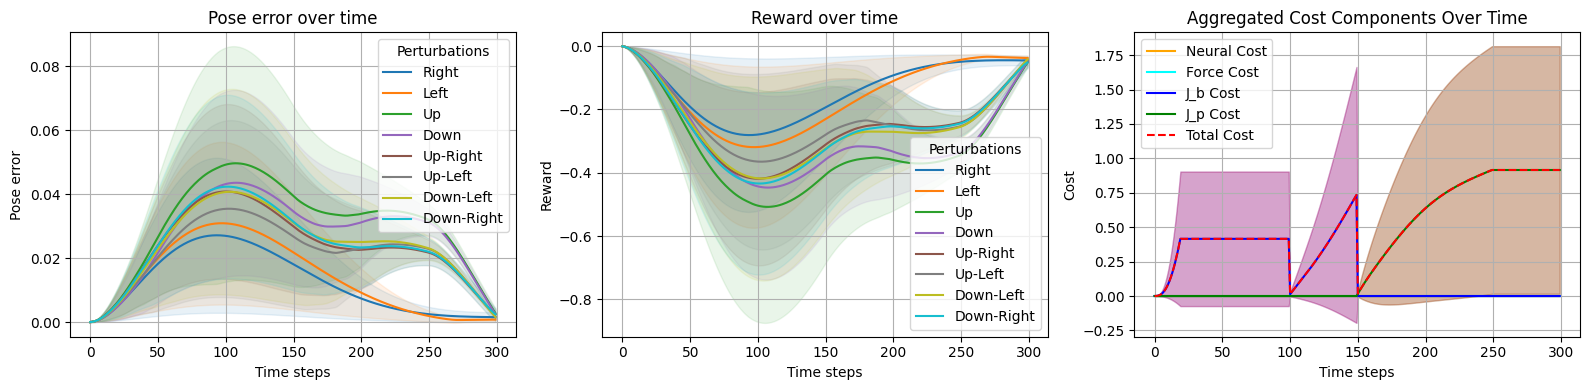

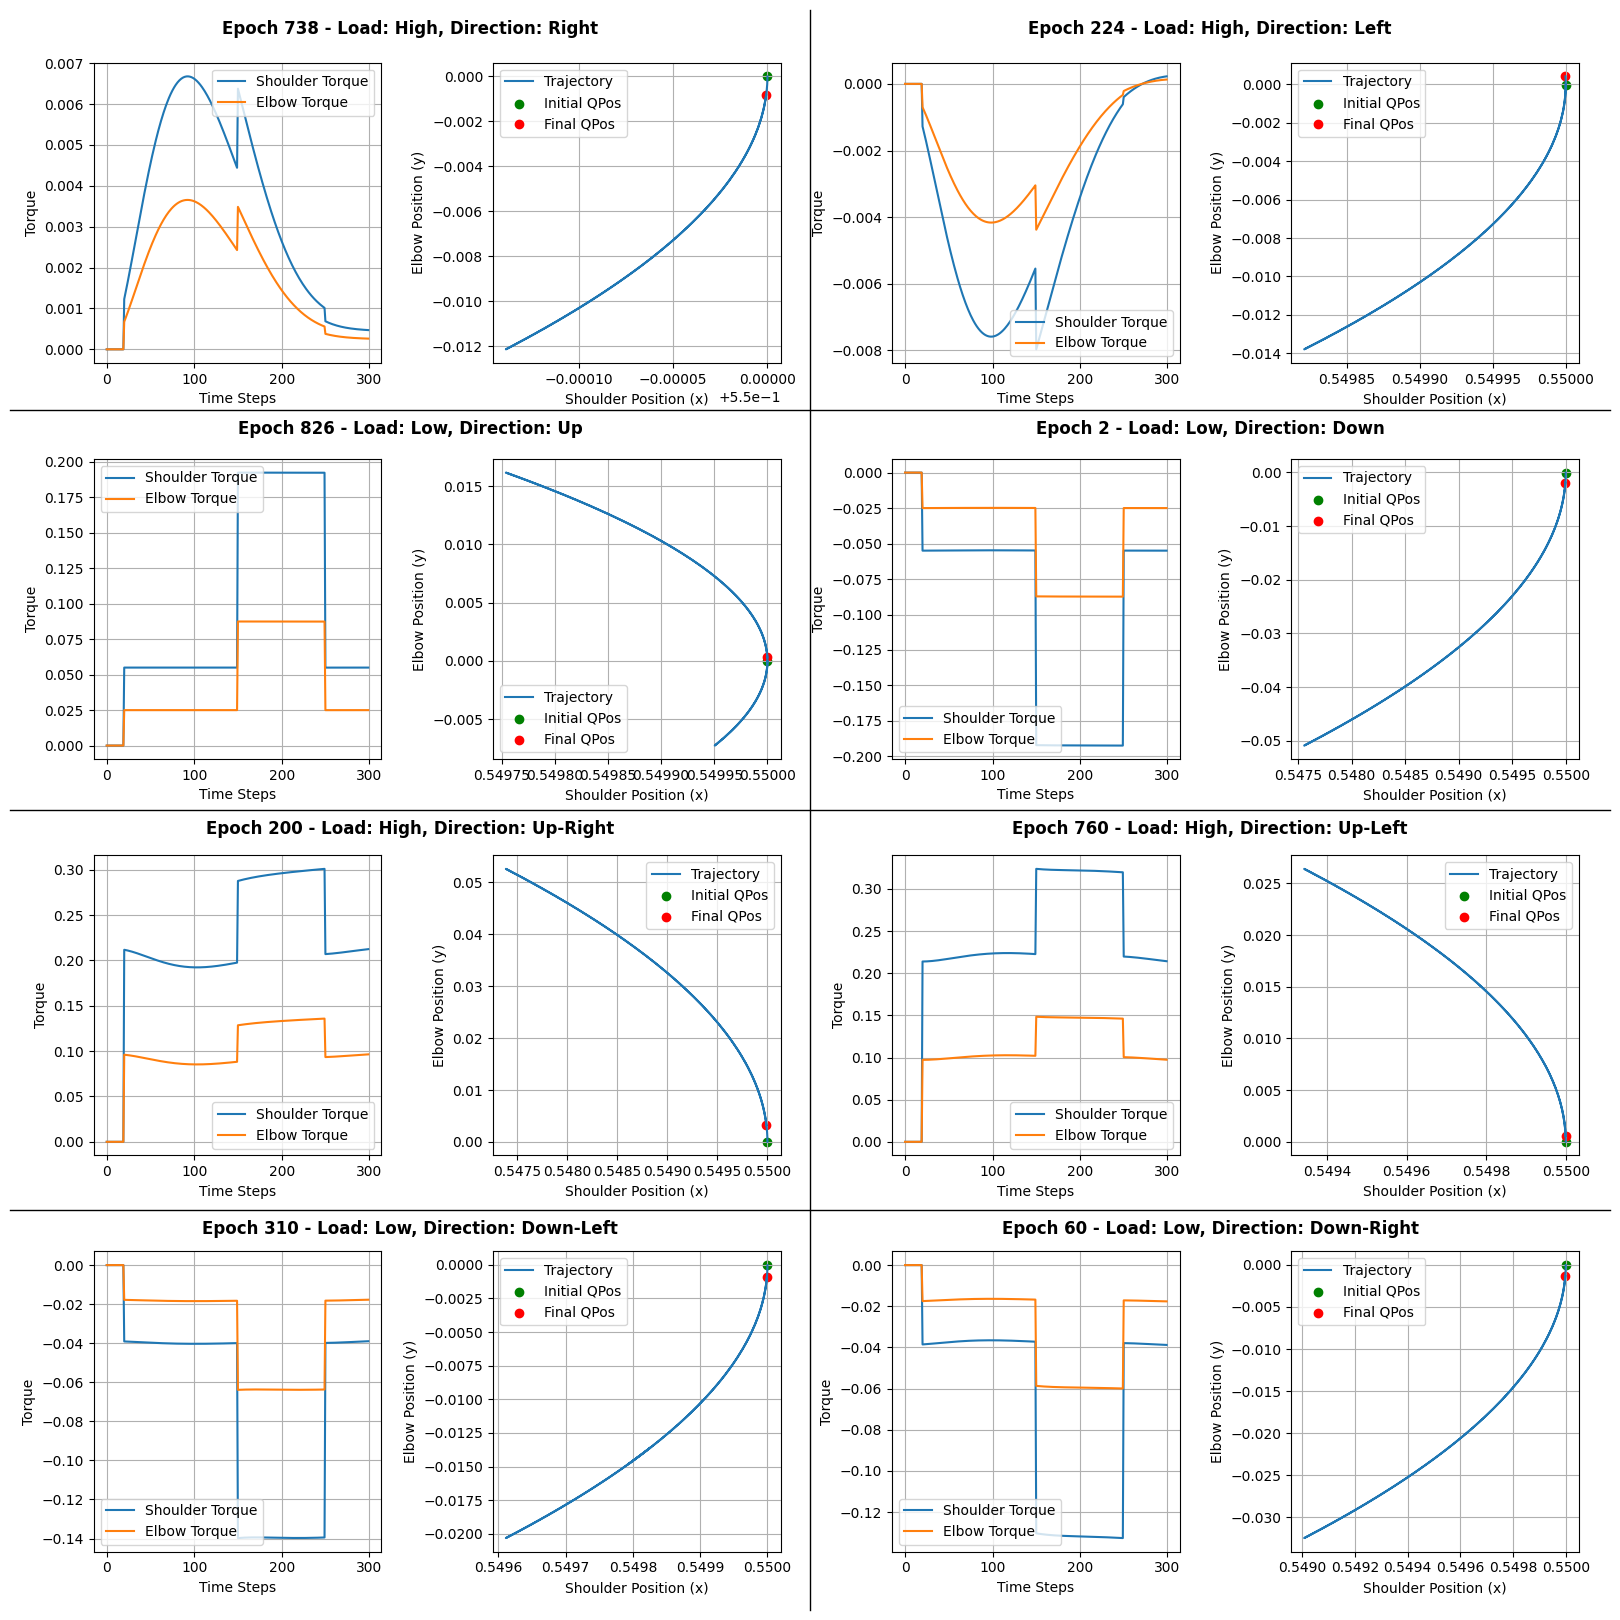

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_pose_error(axes[0], target_results)
plot_reward(axes[1], target_results)
plot_costs(axes[2], epoch_costs_over_time)
plt.tight_layout()
plt.show()

plot_selected_epochs(epoch_metadata, epoch_qpos_over_time, epoch_external_loads)